In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import warnings

In [2]:
df = pd.read_csv("Sales Marketing.csv")

df.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  str    
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  str    
 4   city                        15000 non-null  str    
 5   signup_date                 15000 non-null  str    
 6   last_purchase_date          15000 non-null  str    
 7   acquisition_channel         15000 non-null  str    
 8   device_type                 15000 non-null  str    
 9   subscription_type           15000 non-null  str    
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           15000 non-null

### Exploratory Data Analysis (EDA)

### Memeriksa Missing Value

In [4]:
df.isnull().sum()

customer_id                      0
gender                         738
age                           1200
country                          0
city                             0
signup_date                      0
last_purchase_date               0
acquisition_channel              0
device_type                      0
subscription_type                0
is_premium_user                  0
total_visits                     0
avg_session_time                 0
pages_per_session                0
email_open_rate                  0
email_click_rate                 0
total_spent                   1050
avg_order_value                  0
discount_used                    0
coupon_code                   6133
support_tickets                  0
refund_requested                 0
delivery_delay_days              0
payment_method                   0
satisfaction_score             702
nps_score                        0
marketing_spend_per_user         0
lifetime_value                   0
last_3_month_purchas

### Memeriksa Data Duplikat

In [5]:
df.duplicated().sum()

np.int64(0)

### Memeriksa Outlier

In [6]:
# Memilih kolom numerik untuk pengecekan outlier
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Visualisasi boxplot untuk setiap kolom numerik
plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(5, 4, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot {col}')

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

### Memeriksa Imbalance Data

Distribusi Kolom Churn:
churn
0    12702
1     2298
Name: count, dtype: int64

Persentase Kolom Churn:
churn
0    84.68
1    15.32
Name: proportion, dtype: float64


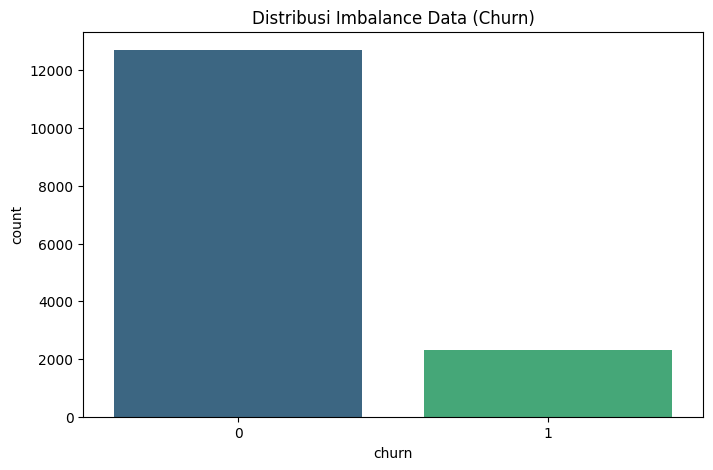

In [ ]:
# Mengecek distribusi target variable (churn) untuk melihat imbalance data
print("Distribusi Kolom Churn:")
print(df['churn'].value_counts())
print("\nPersentase Kolom Churn:")
print(df['churn'].value_counts(normalize=True) * 100)

# Visualisasi distribusi target
plt.figure(figsize=(8, 5))
sns.countplot(x='churn', data=df, palette='viridis')
plt.title('Distribusi Imbalance Data (Churn)')
plt.show()

### Heatmap Correlation

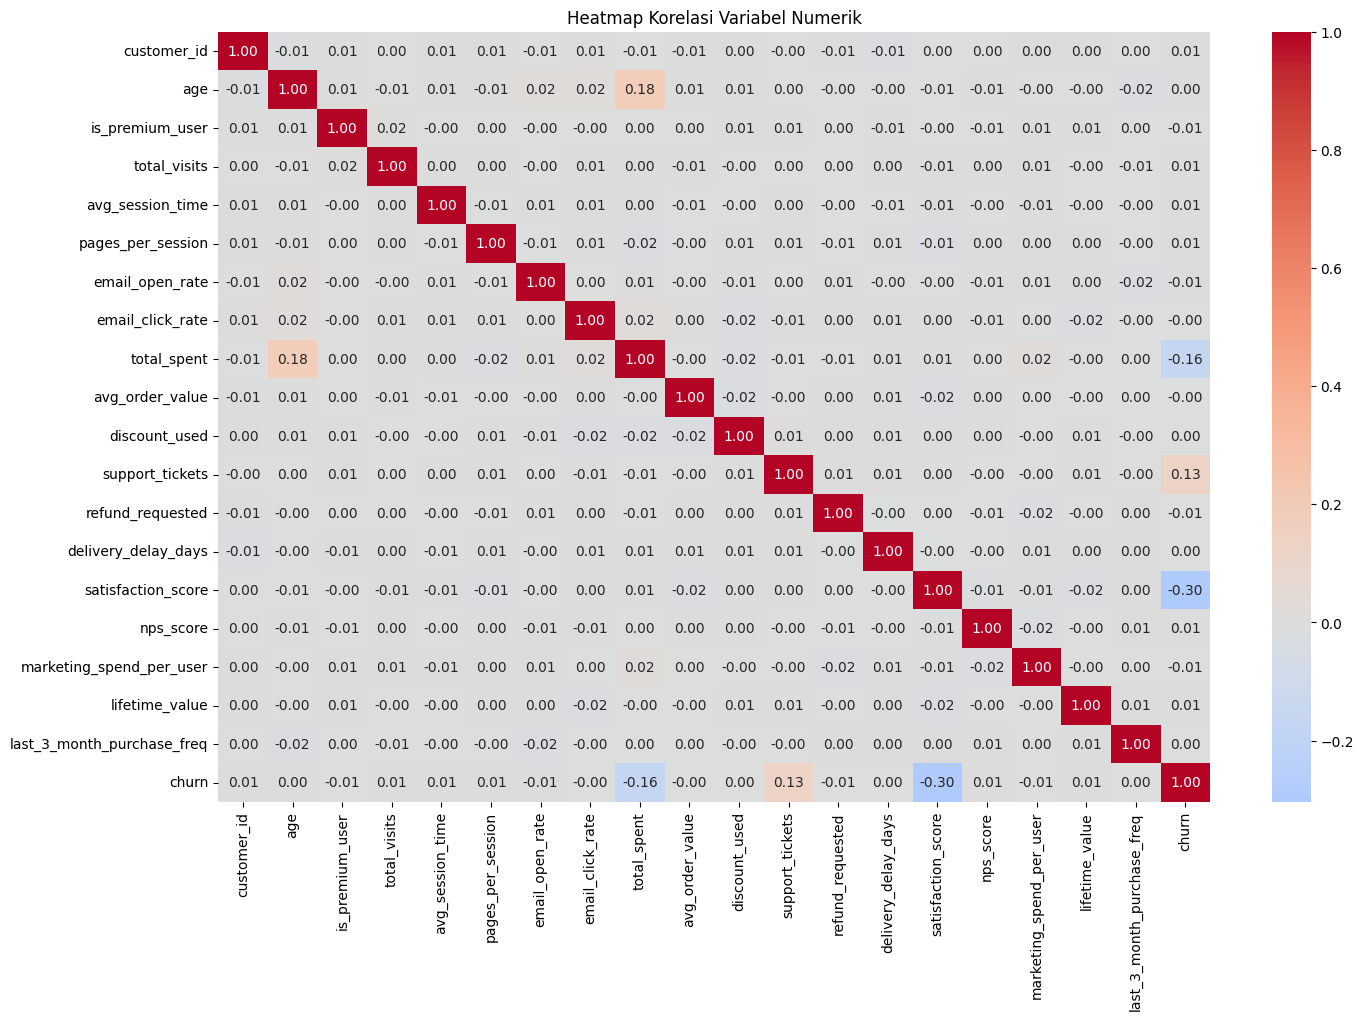

In [ ]:
# Menghitung korelasi antar kolom numerik
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

# Visualisasi heatmap korelasi
plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Heatmap Korelasi Variabel Numerik')
plt.show()

### Direct Modelling

In [ ]:
df_raw = df.select_dtypes(include=[np.number]).dropna()
X_raw = df_raw.drop('churn', axis=1)
y_raw = df_raw['churn']

# Splitting direct modeling
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)


In [ ]:
#Mendefinisikan model-model dasar
model_conv = LogisticRegression(max_iter=1000, random_state=42)
model_bagging = RandomForestClassifier(random_state=42)
model_voting = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=42)),
        ('knn', KNeighborsClassifier()),
        ('svm', SVC(random_state=42))
    ],
    voting='hard'
)

models_baseline = {
    'Logistic Regression (Conv)': model_conv,
    'Random Forest (Bagging)': model_bagging,
    'Voting Classifier (Ensemble)': model_voting
}

print("\n--- PERFORMA DIRECT MODELING (BASELINE) ---")
for name, model in models_baseline.items():
    model.fit(X_train_raw, y_train_raw)
    y_pred_raw = model.predict(X_test_raw)
    f1 = f1_score(y_test_raw, y_pred_raw, zero_division=0)
    print(f"F1-Score {name}: {f1:.4f}")


--- PERFORMA DIRECT MODELING (BASELINE) ---
F1-Score Logistic Regression (Conv): 0.2312
F1-Score Random Forest (Bagging): 0.3988
F1-Score Voting Classifier (Ensemble): 0.0852


### Preprocessing

#### Penanganan Missing Value

In [ ]:
df['is_coupon_used'] = np.where(df['coupon_code'].notnull(), 1, 0)
df = df.drop('coupon_code', axis=1)

In [ ]:
median_age = df['age'].median()
median_total_spent = df['total_spent'].median()

mode_gender = df['gender'].mode()[0]
mode_satisfaction_score = df['satisfaction_score'].mode()[0]

df['age'].fillna(median_age, inplace=True)
df['total_spent'].fillna(median_total_spent, inplace=True)
df['gender'].fillna(mode_gender, inplace=True)
df['satisfaction_score'].fillna(mode_satisfaction_score, inplace=True)

In [ ]:
df.isnull().sum()

,0
customer_id,0
gender,0
age,0
country,0
city,0
signup_date,0
last_purchase_date,0
acquisition_channel,0
device_type,0
subscription_type,0


#### Menangani Outlier

In [ ]:
# Log Transformation for 'total_spent' and 'lifetime_value'
df['total_spent'] = np.log1p(df['total_spent'])


# Capping for other numerical features, including 'lifetime_value' after its transformation
capping_cols = ['age', 'total_visits', 'avg_session_time', 'pages_per_session', 'avg_order_value', 'delivery_delay_days', 'support_tickets']

for col in capping_cols:
    lower_bound = df[col].quantile(0.05)
    upper_bound = df[col].quantile(0.95)
    df[col] = np.clip(df[col], lower_bound, upper_bound)

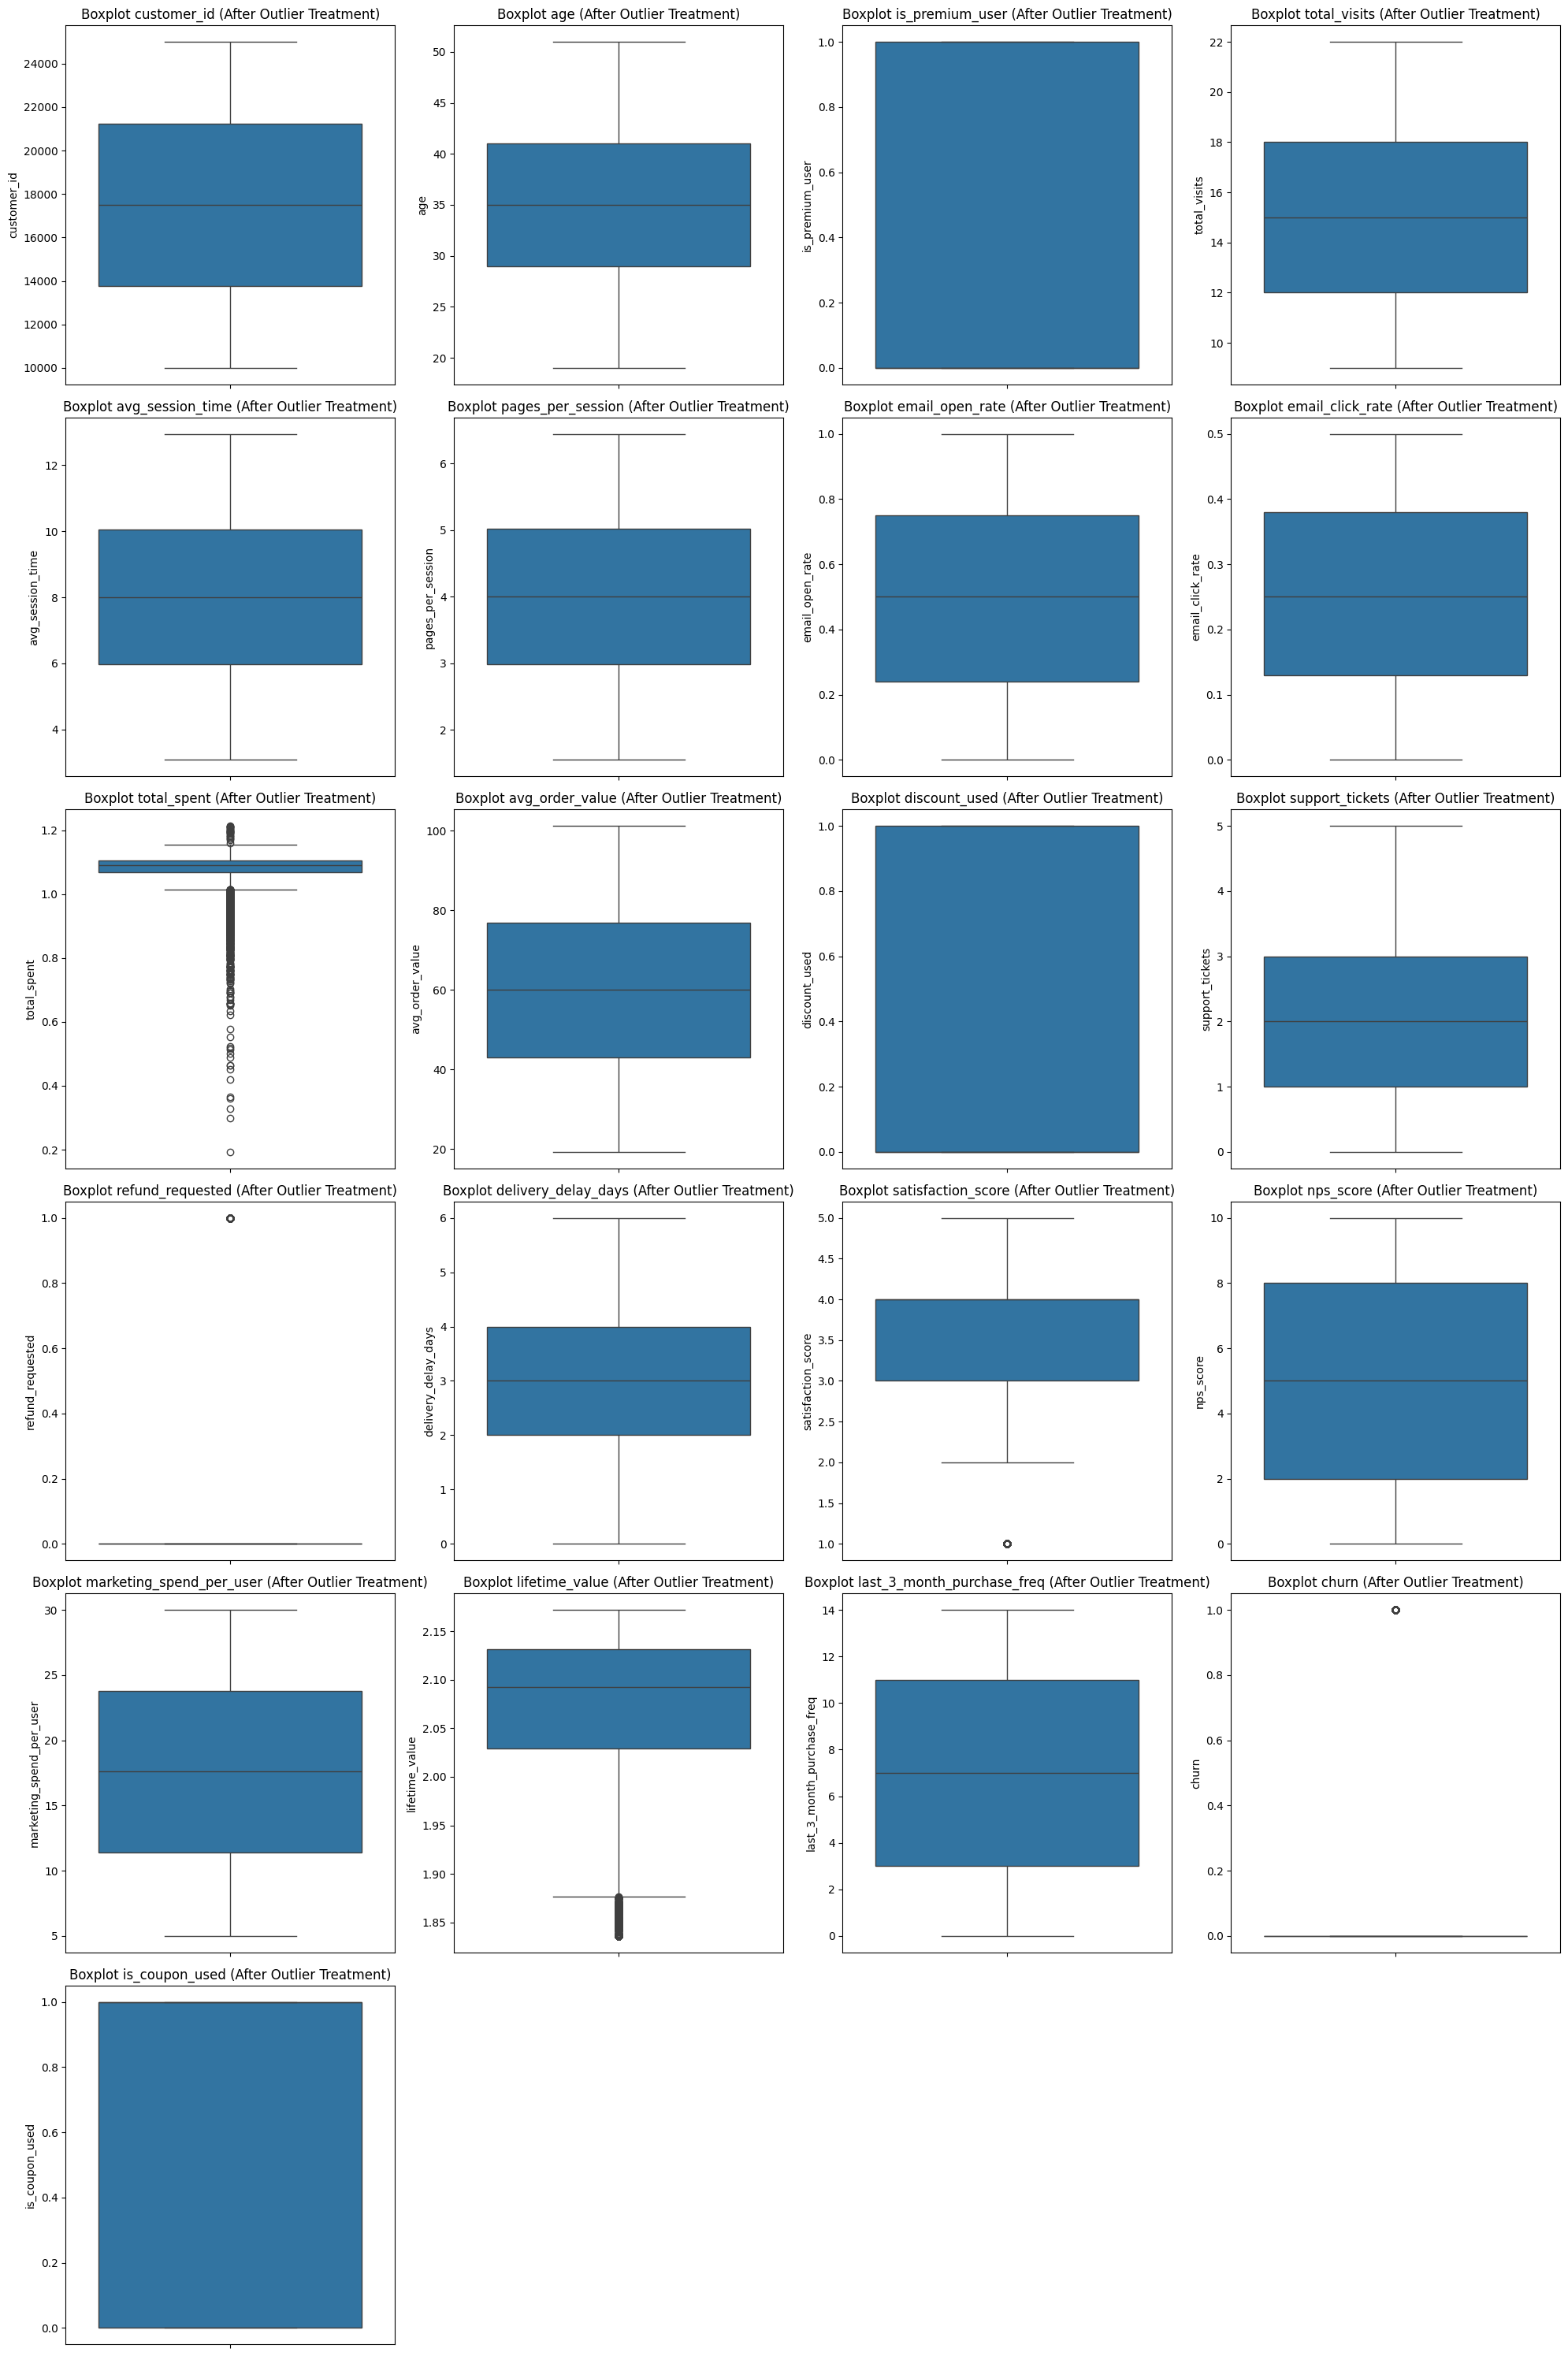

In [ ]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns to check for outliers after treatment
numerical_cols_after_treatment = df.select_dtypes(include=['float64', 'int64']).columns

# Calculate dynamic grid size
cols_per_row = 4
rows_needed = math.ceil(len(numerical_cols_after_treatment) / cols_per_row)

# Visualize box plots for each numerical column after treatment
plt.figure(figsize=(20, 5 * rows_needed)) # Adjust figure height dynamically
for i, col in enumerate(numerical_cols_after_treatment, 1):
    plt.subplot(rows_needed, cols_per_row, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot {col} (After Outlier Treatment)')

plt.tight_layout()
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE only to the processed training data
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)

# Check the new class distribution
print("Distribusi kelas setelah SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

# Verify shapes
print(f"\nShape X_train_balanced: {X_train_balanced.shape}")
print(f"Shape y_train_balanced: {y_train_balanced.shape}")

Distribusi kelas setelah SMOTE:
churn
0    10146
1    10146
Name: count, dtype: int64

Shape X_train_balanced: (20292, 43)
Shape y_train_balanced: (20292,)


In [ ]:
# Initialize models
model_lr_balanced = LogisticRegression(random_state=42, max_iter=1000)
model_rf_balanced = RandomForestClassifier(random_state=42)
model_voting_balanced = VotingClassifier(
    estimators=[('lr', model_lr_balanced), ('rf', model_rf_balanced)],
    voting='soft'
)

# Dictionary of models
balanced_models = {
    'Logistic Regression (Balanced)': model_lr_balanced,
    'Random Forest (Balanced)': model_rf_balanced,
    'Voting Classifier (Balanced)': model_voting_balanced
}

print("--- PERFORMA MODEL DENGAN SMOTE ---")
for name, model in balanced_models.items():
    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test_processed)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    print(f"{name}:")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  Recall  : {recall:.4f}")
    print("-" * 30)

--- PERFORMA MODEL DENGAN SMOTE ---
Logistic Regression (Balanced):
  F1-Score: 0.3774
  Recall  : 0.3761
------------------------------
Random Forest (Balanced):
  F1-Score: 0.5321
  Recall  : 0.5968
------------------------------
Voting Classifier (Balanced):
  F1-Score: 0.4604
  Recall  : 0.4324
------------------------------


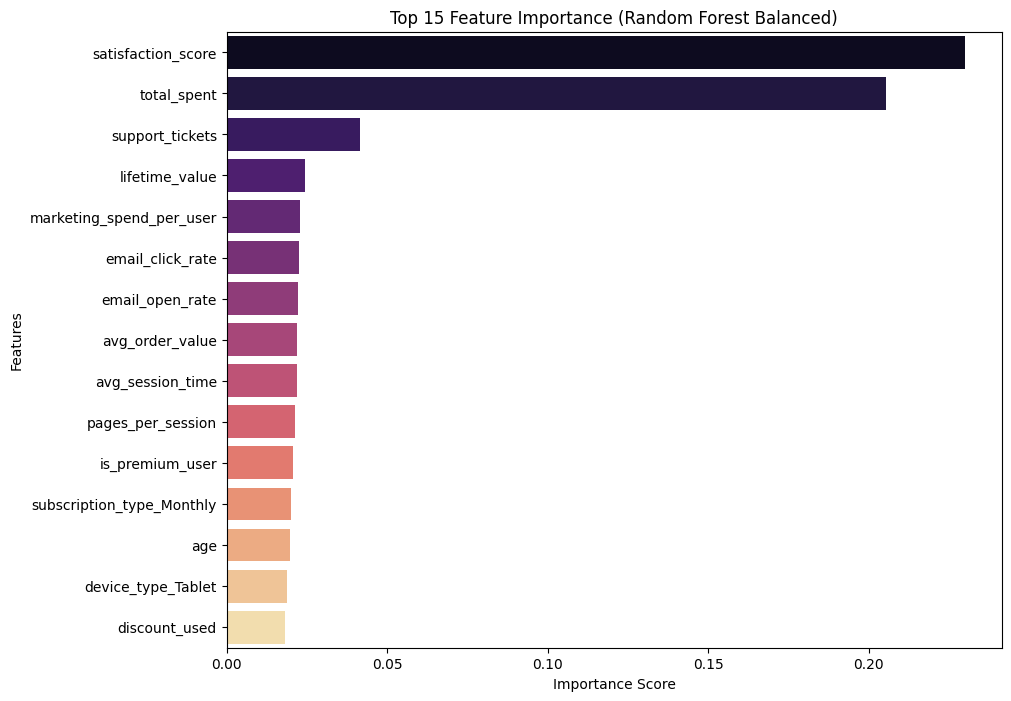

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mendapatkan feature importance dari model Random Forest yang sudah dilatih
importances = model_rf_balanced.feature_importances_
feature_names = X_train_balanced.columns

# Membuat DataFrame untuk memudahkan visualisasi
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Visualisasi 15 fitur teratas
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='magma')
plt.title('Top 15 Feature Importance (Random Forest Balanced)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. Definisi Parameter Grid untuk Logistic Regression
param_grid_lr = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs']
}

# 2. Definisi Parameter Grid untuk Random Forest
param_grid_rf = {
    'n_estimators': [100, 200],
    "max_depth": [10, 20, None],
    'min_samples_split': [2, 5]
}

# Inisialisasi GridSearchCV untuk Logistic Regression
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid_lr, cv=3, scoring='f1', n_jobs=-1)

# Inisialisasi GridSearchCV untuk Random Forest
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=3, scoring='f1', n_jobs=-1)

print("Memulai proses Hyperparameter Tuning... (ini mungkin memakan waktu sebentar)")

# Fitting Logistic Regression
grid_lr.fit(X_train_balanced, y_train_balanced)
print("\n--- BEST LOGISTIC REGRESSION ---")
print(f"Best Parameters: {grid_lr.best_params_}")
print(f"Best Estimator : {grid_lr.best_estimator_}")

# Fitting Random Forest
grid_rf.fit(X_train_balanced, y_train_balanced)
print("\n--- BEST RANDOM FOREST ---")
print(f"Best Parameters: {grid_rf.best_params_}")
print(f"Best Estimator : {grid_rf.best_estimator_}")

Memulai proses Hyperparameter Tuning... (ini mungkin memakan waktu sebentar)

--- BEST LOGISTIC REGRESSION ---
Best Parameters: {'C': 1, 'solver': 'lbfgs'}
Best Estimator : LogisticRegression(C=1, max_iter=1000, random_state=42)

--- BEST RANDOM FOREST ---
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best Estimator : RandomForestClassifier(random_state=42)


In [ ]:
from sklearn.metrics import classification_report

# Mengambil model terbaik dari hasil tuning
best_lr = grid_lr.best_estimator_
best_rf = grid_rf.best_estimator_

models_to_evaluate = {
    'Best Logistic Regression': best_lr,
    'Best Random Forest': best_rf
}

print("--- EVALUASI FINAL MODEL TEROPTIMASI ---")
for name, model in models_to_evaluate.items():
    y_pred_final = model.predict(X_test_processed)

    print(f"\nModel: {name}")
    print(classification_report(y_test, y_pred_final))

    f1 = f1_score(y_test, y_pred_final, zero_division=0)
    rec = recall_score(y_test, y_pred_final, zero_division=0)
    acc = accuracy_score(y_test, y_pred_final)

    print(f"Ringkasan {name}:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Recall  : {rec:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print("-" * 40)

--- EVALUASI FINAL MODEL TEROPTIMASI ---

Model: Best Logistic Regression
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      2556
           1       0.38      0.38      0.38       444

    accuracy                           0.82      3000
   macro avg       0.64      0.63      0.63      3000
weighted avg       0.82      0.82      0.82      3000

Ringkasan Best Logistic Regression:
  Accuracy: 0.8163
  Recall  : 0.3761
  F1-Score: 0.3774
----------------------------------------

Model: Best Random Forest
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      2556
           1       0.48      0.60      0.53       444

    accuracy                           0.84      3000
   macro avg       0.70      0.74      0.72      3000
weighted avg       0.86      0.84      0.85      3000

Ringkasan Best Random Forest:
  Accuracy: 0.8447
  Recall  : 0.5968
  F1-Score: 0.5321
------------------------

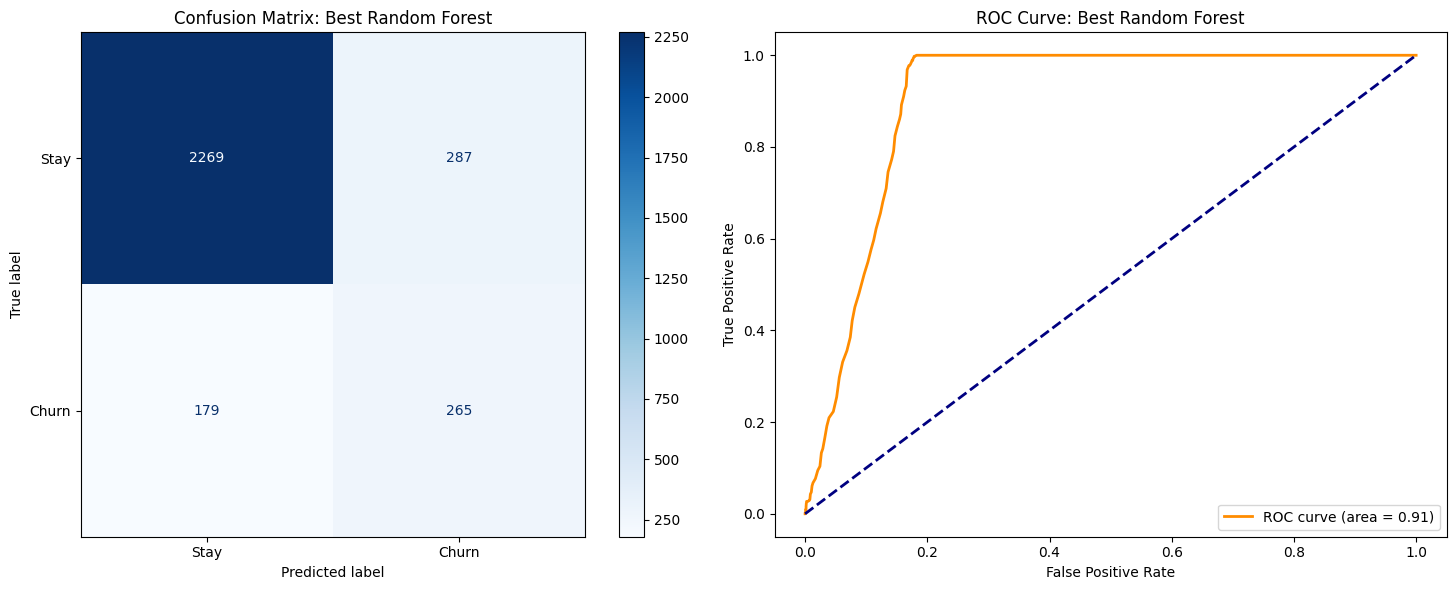

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

# 1. Confusion Matrix untuk Best Random Forest
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

ConfusionMatrixDisplay.from_estimator(best_rf, X_test_processed, y_test,
                                       display_labels=['Stay', 'Churn'],
                                       cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix: Best Random Forest')

# 2. ROC Curve
y_score = best_rf.predict_proba(X_test_processed)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('ROC Curve: Best Random Forest')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()